# IY021 – SimCLR Embeddings + SVM on Experimental GFP Data

**Goal:** Use frozen SimCLR-trained transformer backbones to encode experimental Msn2-mCherry time series, then classify the embeddings with an RBF SVM across glucose environments.

**Models evaluated (28 checkpoints):**
- IY017: instance-norm models, various batch sizes and d_model (D8, D16, D128)
- IY022: single-dataset models with global / joint / batch-wise normalisation
- IY023: mixed-dataset (all 4 sources) models with batch-wise normalisation

---

### TF structure of the experiments

Each experiment contains multiple yeast strains ("groups"), each expressing **Msn2-mCherry** alongside a strain-specific **GFP-TF**. Classifications are only meaningful when comparing the **same strain** under different glucose conditions.

| Experiment | Glucose | group 1344 (Cat8-GFP) | group 1346 (Nrg1-GFP) | group 1347 (Rtg1-GFP) | Other groups |
|---|---|---|---|---|---|
| 19316 | **2%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 19554 | 0.01% | — | — | — | 900=Mig1/Msn2, 756/903=unknown |
| 19566 | **0.1%** | ⚠️ TF uncertain | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 20213 | **0.01%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |

**Exclusions (with reason):**
- **19554 entirely**: Mig1-GFP strain (group 900) not comparable to Nrg1/Rtg1/Cat8; groups 756/903 unidentified
- **19566 / group 1344**: TF identity ambiguous (absent from OMERO metadata for this experiment)

**Included for 3-way classification (2% vs 0.1% vs 0.01%):**  
Groups **1346 (Nrg1)** and **1347 (Rtg1)** — the only strains present across all 3 glucose conditions.

**Key difference from IY022/IY023 downstream notebooks:**  
Those notebooks encode *pairs* and use `|z1−z2|` for same/different verification.  
Here we encode *individual* series via `backbone.encode()` and classify embeddings directly (multi-class task).

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

# stochastic_sim source
sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

# wela lives in a separate env (requires numpy<2, incompatible with stochastic_sim).
# Add both editable-install source roots so wela is importable without touching
# this environment's numpy.
sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

np.random.seed(42)
torch.manual_seed(42)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
EXP_DIR  = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]

print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Experimental Data & Assign Labels

In [2]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}

print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))
    else:
        print("  (no TF metadata)")

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [3]:
FILE_REGISTRY = {
    # --- 2% glucose (label 0) ---
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series":
        (0, "2%",   "Nrg1", "GFP"),
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series":
        (0, "2%",   "Rtg1", "GFP"),
    # --- 0.1% glucose (label 1) ---
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series":
        (1, "0.1%", "Nrg1", "GFP"),
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series":
        (1, "0.1%", "Rtg1", "GFP"),
    # --- 0.01% glucose (label 2) ---
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series":
        (2, "0.01%", "Nrg1", "GFP"),
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series":
        (2, "0.01%", "Rtg1", "GFP"),
}
# Exclusions (with reason):
#   19554 entirely  – Mig1-GFP (group 900) not comparable; groups 756/903 TF unknown
#   19566/group1344 – TF identity ambiguous (absent from OMERO metadata)
#   Cat8 (group1344 in 19316/20213) – only present in 2 of 3 conditions; excluded for balance

label_names = {0: "2% glucose", 1: "0.1% glucose", 2: "0.01% glucose"}
META_COLS   = ["id", "group", "experiment"]

all_X, all_y, all_strain = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem
    if stem not in FILE_REGISTRY:
        continue
    glucose_label, glucose_pct, gfp_tf, channel = FILE_REGISTRY[stem]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_X.append(ts)
    all_y.extend([glucose_label] * len(ts))
    all_strain.extend([gfp_tf] * len(ts))
    print(f"  Loaded: {gfp_tf} (GFP) @ {glucose_pct} glc  "
          f"({ts.shape[0]} cells × {ts.shape[1]} tp)")

# Files have different numbers of timepoints — truncate to the shortest
min_tp = min(ts.shape[1] for ts in all_X)
print(f"\nTruncating all series to {min_tp} timepoints (shortest file)")
all_X = [ts[:, :min_tp] for ts in all_X]

X_raw   = np.vstack(all_X)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    mask = y == lbl
    strain_counts = {s: int(np.sum(strains[mask] == s)) for s in np.unique(strains[mask])}
    print(f"  {lbl}: {name:15s} → {mask.sum():4d} cells  {strain_counts}")

  Loaded: Nrg1 (GFP) @ 2% glc  (84 cells × 232 tp)
  Loaded: Rtg1 (GFP) @ 2% glc  (78 cells × 146 tp)
  Loaded: Nrg1 (GFP) @ 0.1% glc  (231 cells × 219 tp)
  Loaded: Rtg1 (GFP) @ 0.1% glc  (200 cells × 80 tp)
  Loaded: Nrg1 (GFP) @ 0.01% glc  (231 cells × 104 tp)
  Loaded: Rtg1 (GFP) @ 0.01% glc  (275 cells × 165 tp)

Truncating all series to 80 timepoints (shortest file)
Dataset: 1099 cells × 80 timepoints
  0: 2% glucose      →  162 cells  {np.str_('Nrg1'): 84, np.str_('Rtg1'): 78}
  1: 0.1% glucose    →  431 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 200}
  2: 0.01% glucose   →  506 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 275}


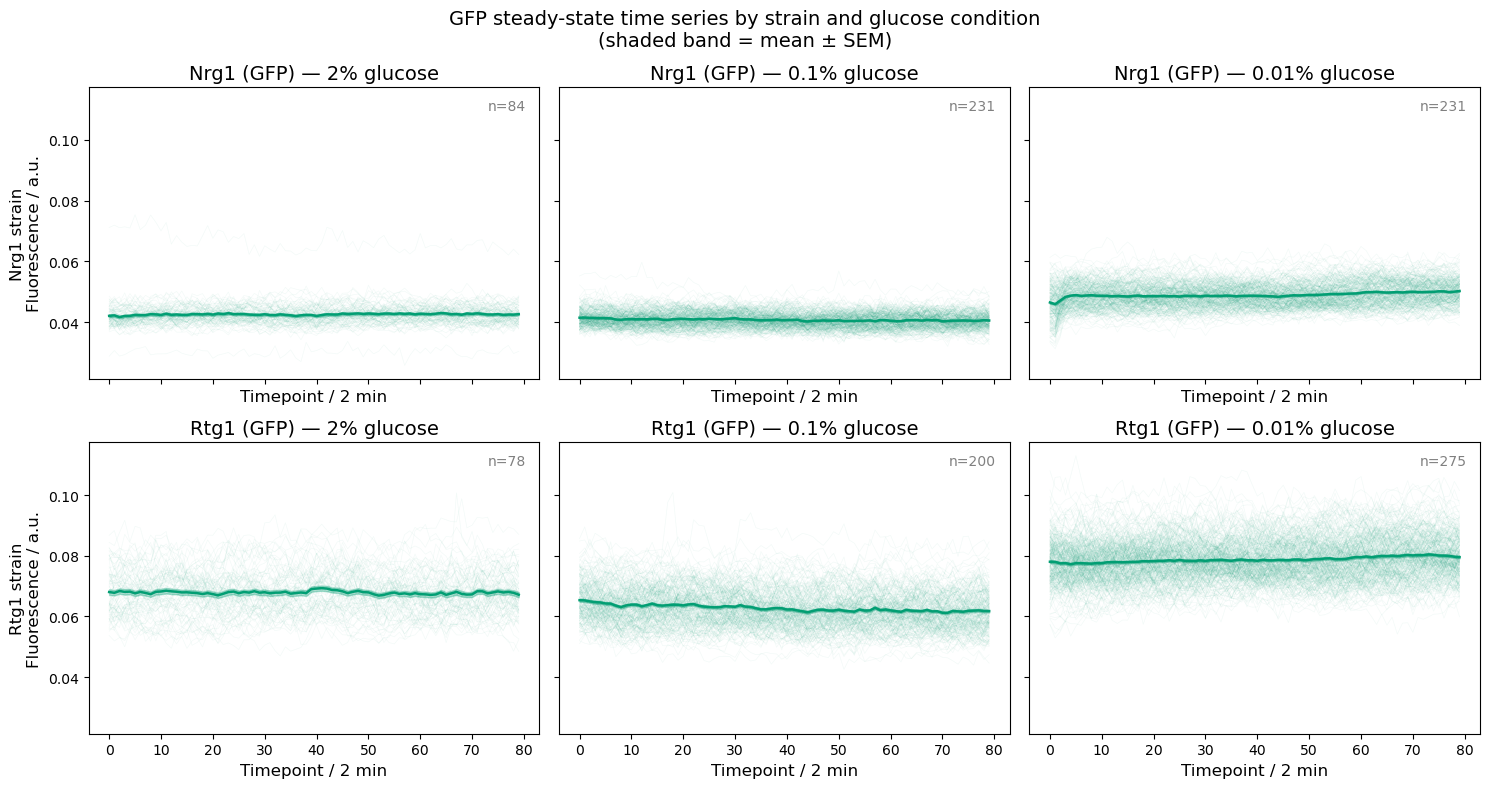

In [4]:
import seaborn as sns

plt.rcParams.update({"font.family": "sans-serif"})
palette  = sns.color_palette("colorblind")
ch_color = palette[2]  # green — GFP

tfs        = ["Nrg1", "Rtg1"]
conditions = sorted(label_names.keys())
n_tp       = X_raw.shape[1]
t_axis     = np.arange(n_tp)
n_rows, n_cols = len(tfs), len(conditions)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True, sharex=True,
)

for row, tf in enumerate(tfs):
    for col, lbl in enumerate(conditions):
        ax    = axes[row][col]
        mask  = (y == lbl) & (strains == tf)
        X_sub = X_raw[mask]

        for trace in X_sub:
            ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)

        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            sem  = np.nanstd(X_sub, axis=0) / np.sqrt(len(X_sub))
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sem, mean + sem, color=ch_color, alpha=0.3)

        ax.set_title(f"{tf} (GFP) — {label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=10, color="gray")

fig.suptitle(
    "GFP steady-state time series by strain and glucose condition\n"
    "(shaded band = mean ± SEM)",
    fontsize=14,
)
plt.tight_layout()
plt.show()


## 2. Preprocessing: NaN Fill, Balance & Normalize

In [5]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean",
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

def batch_wise_normalize(X, mean=None, std=None):
    """
    Z-score per timepoint (across the sample axis).
    If mean/std are provided, use them (for applying train stats to test).
    Returns (X_norm, mean, std).
    """
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)   # (1, T)
        std  = X.std( axis=0, keepdims=True)
    return (X - mean) / std, mean, std

X_clean = fill_nans(X_raw)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])
X_bal = X_clean[bal_idx]
y_bal = y[bal_idx]

# Train / test split first, then normalise using train statistics only
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

X_train, norm_mean, norm_std = batch_wise_normalize(X_train_raw)
X_test,  _,         _        = batch_wise_normalize(X_test_raw, mean=norm_mean, std=norm_std)

print(f"Balanced: {X_bal.shape[0]} cells  |  class counts: {np.bincount(y_bal)}")
print(f"Train {X_train.shape[0]}  |  Test {X_test.shape[0]}")
print("Normalisation: batch-wise z-score fit on train, applied to test")

NaN remaining: 0
Balancing to 162 samples per class
Balanced: 486 cells  |  class counts: [162 162 162]
Train 388  |  Test 98
Normalisation: batch-wise z-score fit on train, applied to test


## 3. SimCLR Model Registry & Helper Functions

In [6]:
import re

# Known norm method overrides for files whose filename doesn't contain a keyword
# (from comments in IY022_downsteam_svm.ipynb and IY023_simclr_svm_downstream.ipynb)
NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

def parse_arch_from_name(name: str) -> dict:
    d_model    = int(re.search(r"_D(\d+)", name).group(1))
    nhead      = int(re.search(r"_H(\d+)", name).group(1))
    num_layers = int(re.search(r"_L(\d+)", name).group(1))
    return dict(input_size=1, d_model=d_model, nhead=nhead,
                num_layers=num_layers, dropout=0.01, use_conv1d=False)

def make_short_label(path: Path) -> str:
    exp    = path.parts[-2]
    stem   = path.stem
    exp_id = re.search(r"IY\d+", exp).group()

    bs = re.search(r"_b(\d+)", stem)
    bs = f"b{bs.group(1)}" if bs else ""

    dm = re.search(r"_D(\d+)", stem)
    dm = f"D{dm.group(1)}" if dm else ""

    # Normalisation: explicit keywords first, then override dict, then 'inst'
    if   "batch-wise" in stem:   norm = "batch"
    elif "global"     in stem:   norm = "global"
    elif "joint"      in stem:   norm = "joint"
    elif "mixed"      in stem:   norm = "mixed"
    elif stem in NORM_OVERRIDES: norm = NORM_OVERRIDES[stem]
    else:                        norm = "inst"

    return f"{exp_id}-{norm} {bs} {dm}".strip()

# Auto-discover all checkpoints across IY017, IY022, IY023
CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for d in CKPT_DIRS:
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append((p, make_short_label(p)))

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for p, lbl in MODEL_REGISTRY:
    arch = parse_arch_from_name(p.name)
    print(f"  [{p.parts[-2]}]  {lbl:<42s}  d_model={arch['d_model']}")

# -----------------------------------------------------------------------

def load_model(checkpoint_path, device):
    kwargs = parse_arch_from_name(checkpoint_path.name)
    model  = SSL_Transformer(**kwargs)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

def encode_dataset(model, X_np, device, batch_size=256):
    """Encode (N, T) array → (N, D) embeddings via frozen backbone.encode()."""
    embeddings = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            chunk = X_np[start : start + batch_size]
            x = torch.from_numpy(chunk).float().unsqueeze(-1).to(device)  # (B, T, 1)
            h = model.backbone.encode(x)                                   # (B, D)
            embeddings.append(h.cpu().numpy())
    return np.concatenate(embeddings, axis=0)

def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    """Extract embeddings → StandardScale → SVM (RBF) → (accuracy, y_pred)."""
    Z_tr = encode_dataset(model, X_tr, device)
    Z_te = encode_dataset(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128                        d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128                        d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16                         d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                          d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                          d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16                         d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128                         d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b512 D16                         d_model=16
  [EXP-26-IY017]  IY017-in

## 4. Run All Models

In [7]:
results = {}  # {label: (accuracy, y_pred)}

for ckpt_path, label in MODEL_REGISTRY:
    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")

    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm(model, X_train, X_test, y_train, y_test, DEVICE)
        results[label] = (acc, y_pred)
        print(f"  Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  FAILED: {e}")
        results[label] = (np.nan, None)

print("\n\n=== Summary ===")
for label, (acc, _) in results.items():
    print(f"  {label:<35s}  {acc:.4f}" if not np.isnan(acc) else f"  {label:<35s}  FAILED")


Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth


  Accuracy: 0.6735

Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.5918

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.6429

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.6327

Model: IY017-inst b128 D16
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.7347

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.6327

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.5306

Model: IY017-inst b2048 D16
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.6531

Model: IY017-inst b256 D16
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.6327

Model: IY017-inst b32 D128
  IY017_simCLR_b32_lr0.01_L2_H4_D128_model.pth
  Accuracy: 0.6939

Model: IY017-inst b4096 D16
  IY017_si

## 5. Results Visualisation

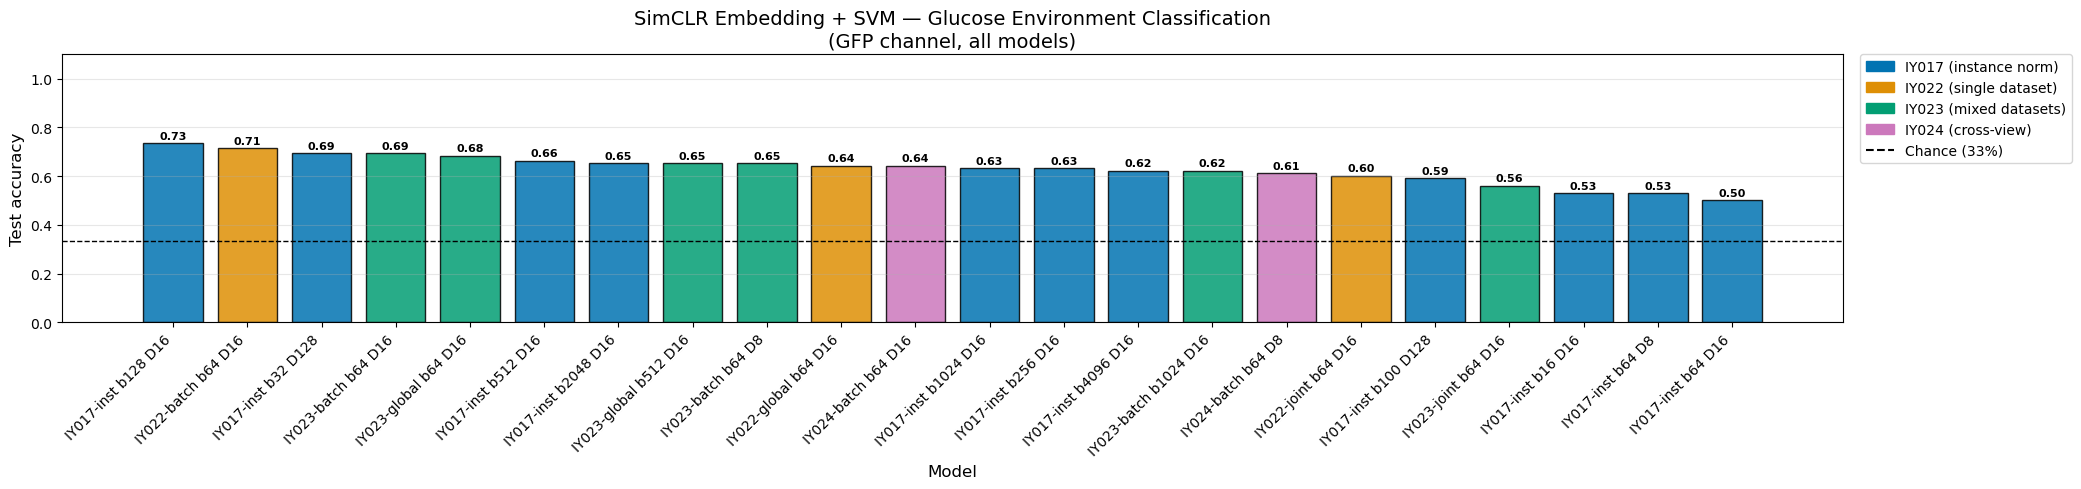

In [8]:
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams.update({"font.family": "sans-serif"})
palette = sns.color_palette("colorblind")

valid_results = dict(sorted(
    ((k, v) for k, v in results.items() if not np.isnan(v[0])),
    key=lambda item: item[1][0],
    reverse=True,
))
model_labels  = list(valid_results.keys())
accs          = [valid_results[k][0] for k in model_labels]
class_names   = [label_names[i] for i in sorted(label_names)]
chance        = 1 / len(label_names)

color_map = {
    "IY017": palette[0],
    "IY022": palette[1],
    "IY023": palette[2],
    "IY024": palette[4],
}
bar_colors = [color_map.get(next((k for k in color_map if k in lbl), ""), palette[7])
              for lbl in model_labels]

fig, ax = plt.subplots(figsize=(max(12, len(model_labels) * 0.95), 5))
bars = ax.bar(range(len(model_labels)), accs, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.0)
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_title(
    "SimCLR Embedding + SVM — Glucose Environment Classification\n(GFP channel, all models)",
    fontsize=14,
)
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.legend(handles=[
    Patch(color=palette[0], label="IY017 (instance norm)"),
    Patch(color=palette[1], label="IY022 (single dataset)"),
    Patch(color=palette[2], label="IY023 (mixed datasets)"),
    Patch(color=palette[4], label="IY024 (cross-view)"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.0%})"),
], fontsize=10, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("IY021_simclr_svm_results.png", dpi=150, bbox_inches="tight")
plt.show()


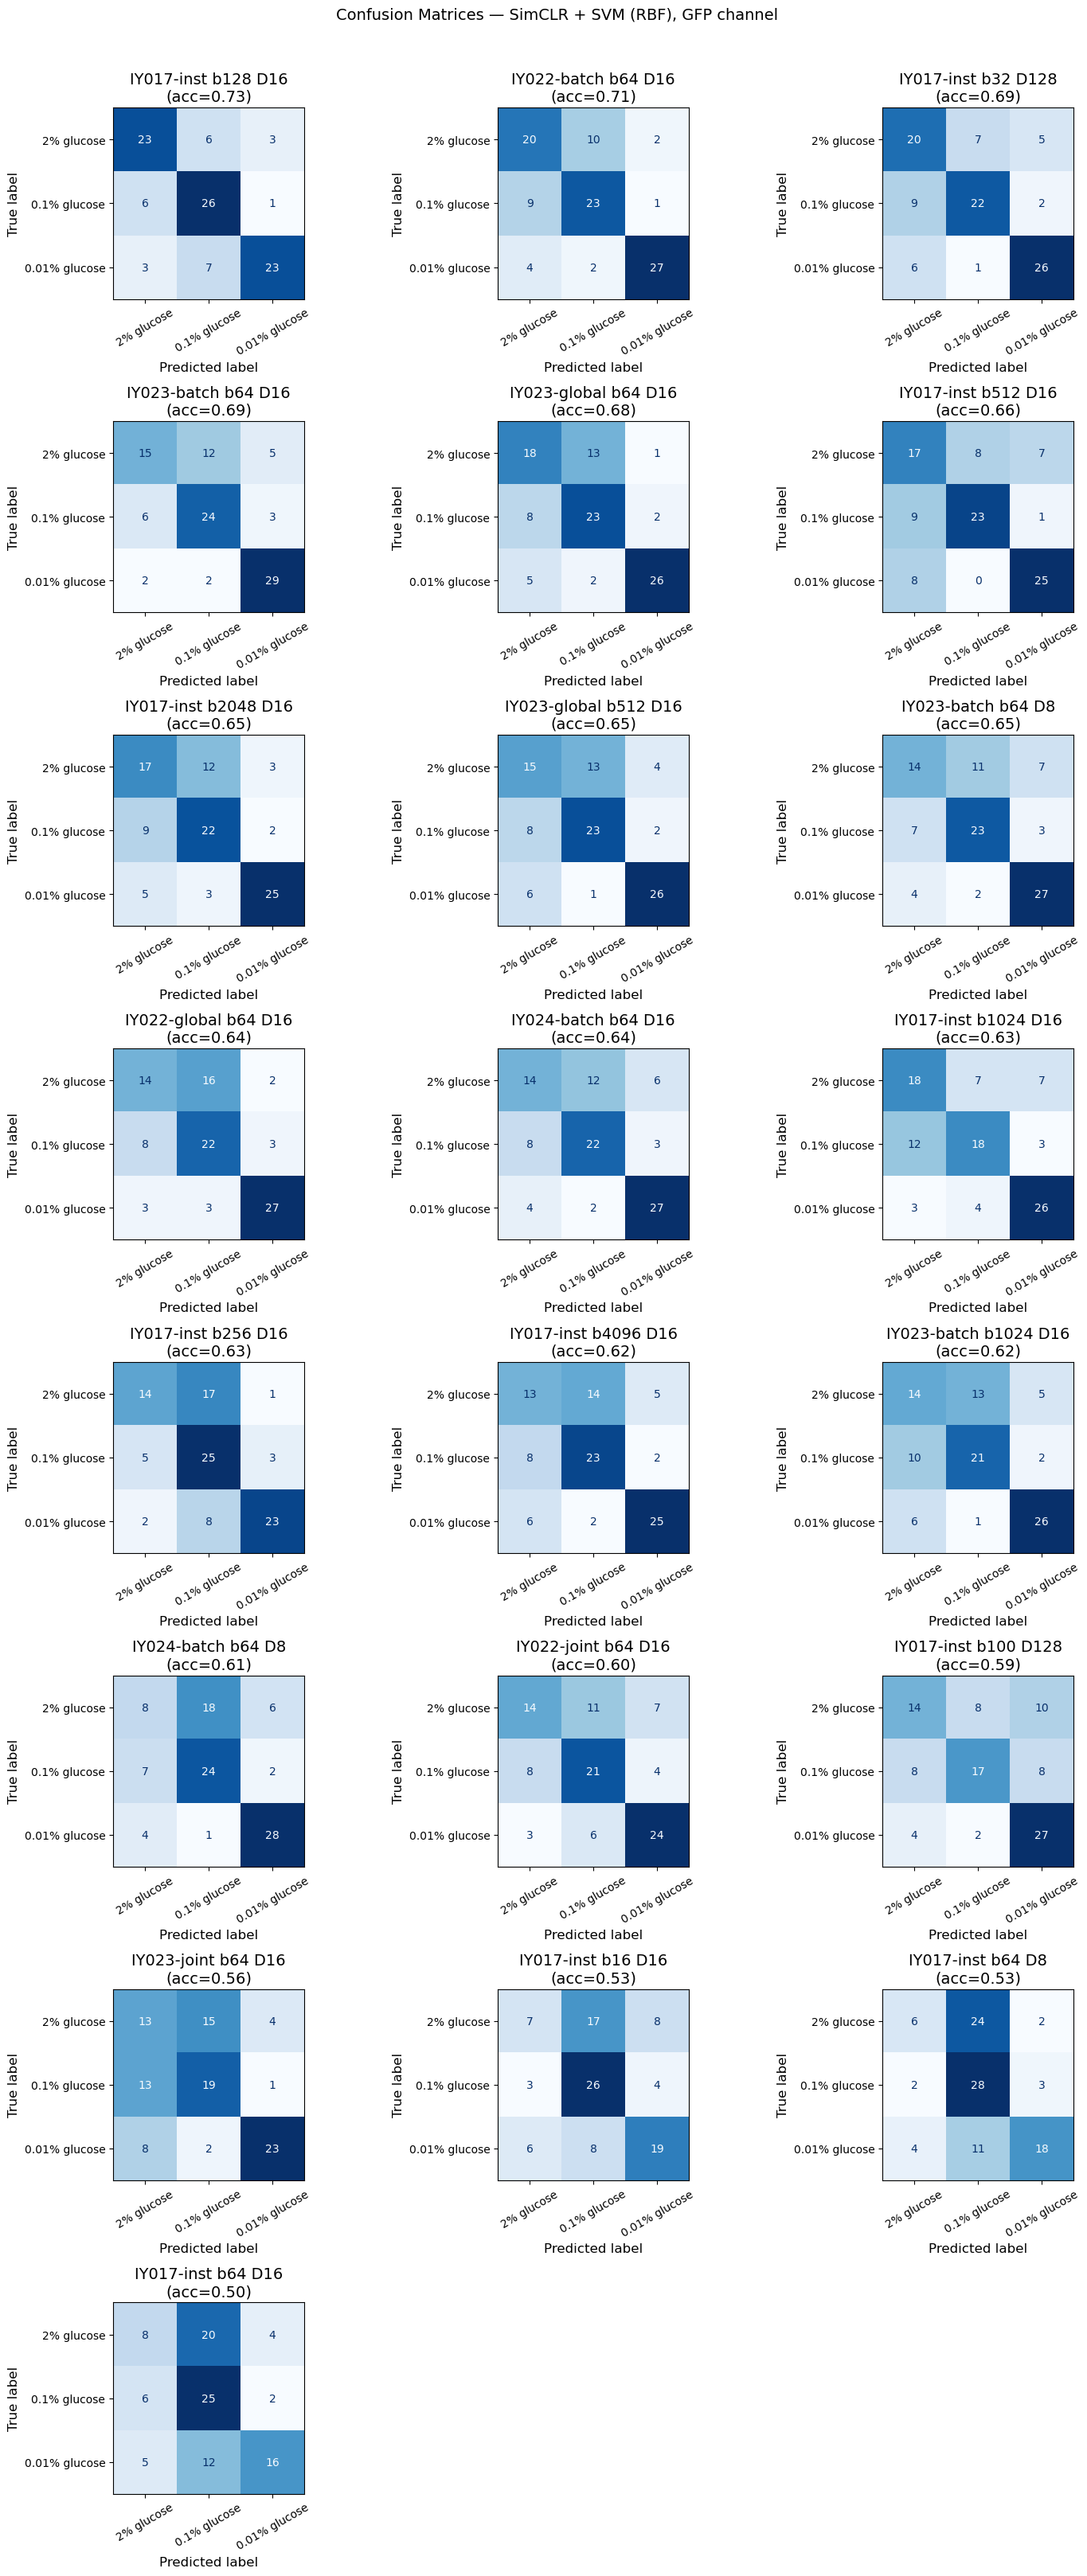

In [9]:
import seaborn as sns

plt.rcParams.update({"font.family": "sans-serif"})

n_valid = len(valid_results)
if n_valid > 0:
    ncols = min(3, n_valid)
    nrows = (n_valid + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n_valid > 1 else [axes]

    for ax, (lbl, (acc, y_pred)) in zip(axes, valid_results.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=class_names,
            ax=ax,
            colorbar=False,
            cmap="Blues",
        )
        ax.set_title(f"{lbl}\n(acc={acc:.2f})", fontsize=14)
        ax.set_xlabel("Predicted label", fontsize=12)
        ax.set_ylabel("True label", fontsize=12)
        ax.tick_params(axis="x", rotation=30, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

    for ax in axes[n_valid:]:
        ax.set_visible(False)

    plt.suptitle("Confusion Matrices — SimCLR + SVM (RBF), GFP channel", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("IY021_simclr_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
